In [1]:
import os 
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/shogohuangg/training-scaffold/2313.csv
/kaggle/input/datasets/shogohuangg/training-scaffold/2431.csv
/kaggle/input/datasets/shogohuangg/training-scaffold/2659.csv
/kaggle/input/datasets/shogohuangg/training-scaffold/2244.csv
/kaggle/input/datasets/shogohuangg/training-scaffold/2186.wav
/kaggle/input/datasets/shogohuangg/training-scaffold/2191.wav
/kaggle/input/datasets/shogohuangg/training-scaffold/2432.wav
/kaggle/input/datasets/shogohuangg/training-scaffold/1805.csv
/kaggle/input/datasets/shogohuangg/training-scaffold/1789.wav
/kaggle/input/datasets/shogohuangg/training-scaffold/2178.csv
/kaggle/input/datasets/shogohuangg/training-scaffold/2179.csv
/kaggle/input/datasets/shogohuangg/training-scaffold/1790.wav
/kaggle/input/datasets/shogohuangg/training-scaffold/2288.csv
/kaggle/input/datasets/shogohuangg/training-scaffold/2315.wav
/kaggle/input/datasets/shogohuangg/training-scaffold/2105.csv
/kaggle/input/datasets/shogohuangg/training-scaffold/2243.wav
/kaggle/

2.10.0+cu128
True
20 training files,  5 testing files
Spectrogram shape: torch.Size([1, 1025, 38280])
Piano roll shape: torch.Size([38280, 88])


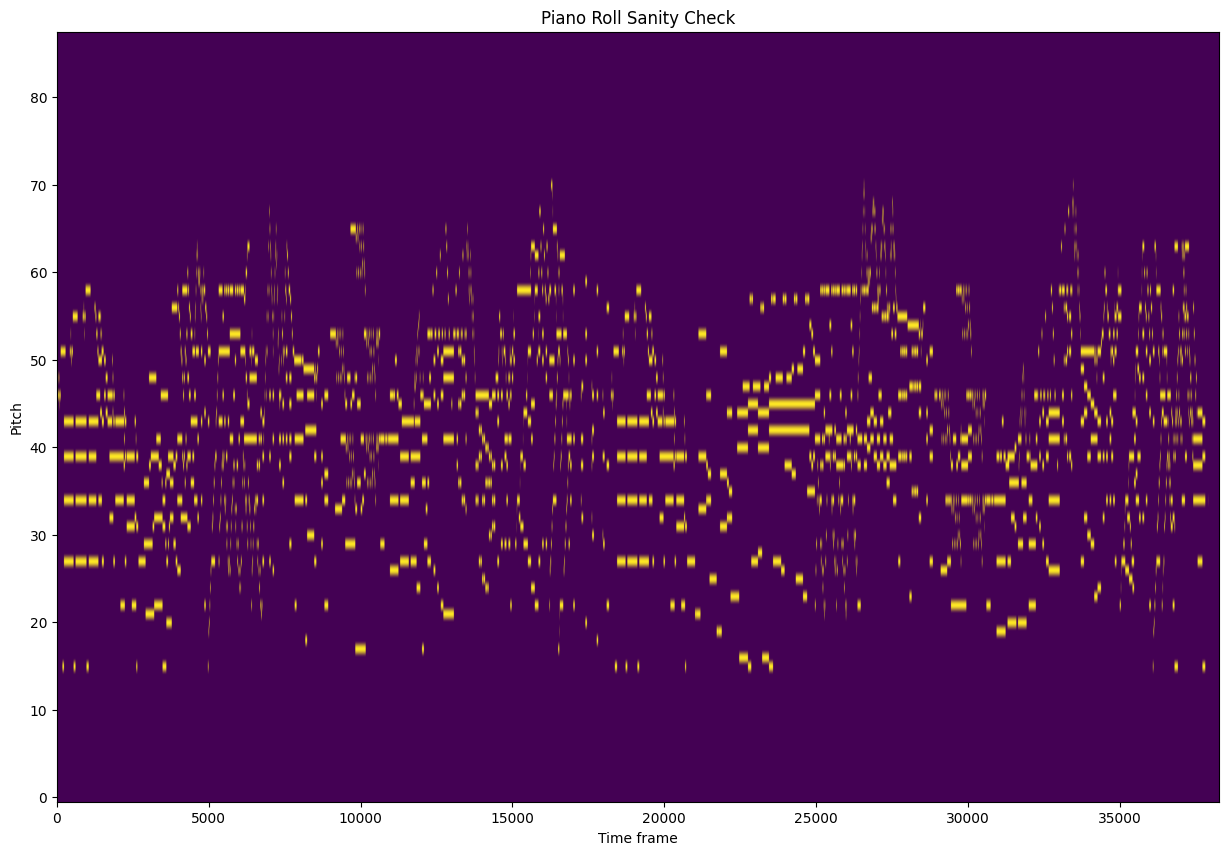

CRNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=(4, 1), stride=(4, 1), padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=(4, 1), stride=(4, 1), padding=0, dilation=1, ceil_mode=False)
  (lstm): LSTM(1024, 128, num_layers=2, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=88, bias=True)
)
torch.Size([1, 300, 88])
Loading training
  train piece 1/20: 128 chunks (38280 frames)
  train piece 2/20: 84 chunks (25133 frames)
  train piece 3/20: 141 chunks (42278 frames)
  train piece 4/20: 102 chunks (30598 frames)
  train piece 5/20: 146 chunks (43502 frames)
  train pie

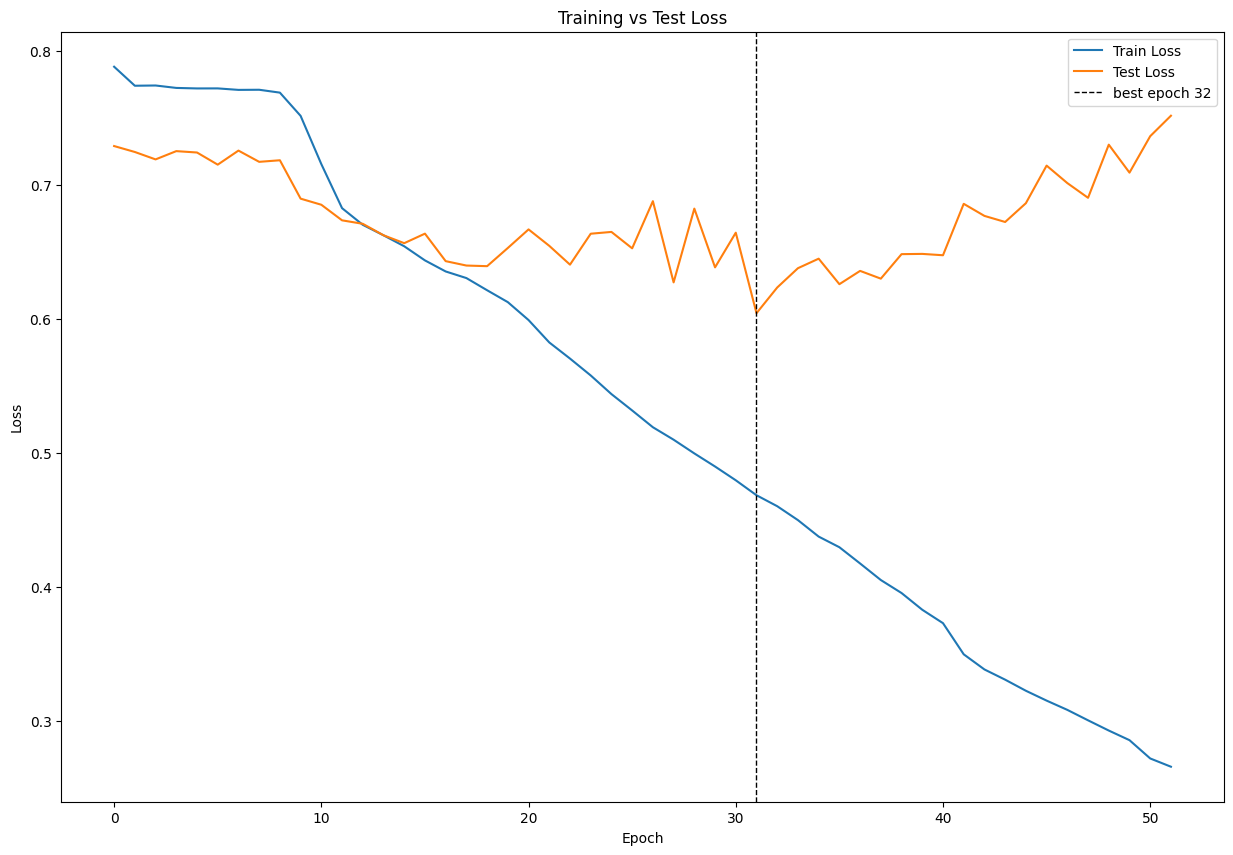

probs min/max/mean: 1.2948827565750776e-09 0.9909130334854126 0.20556534826755524


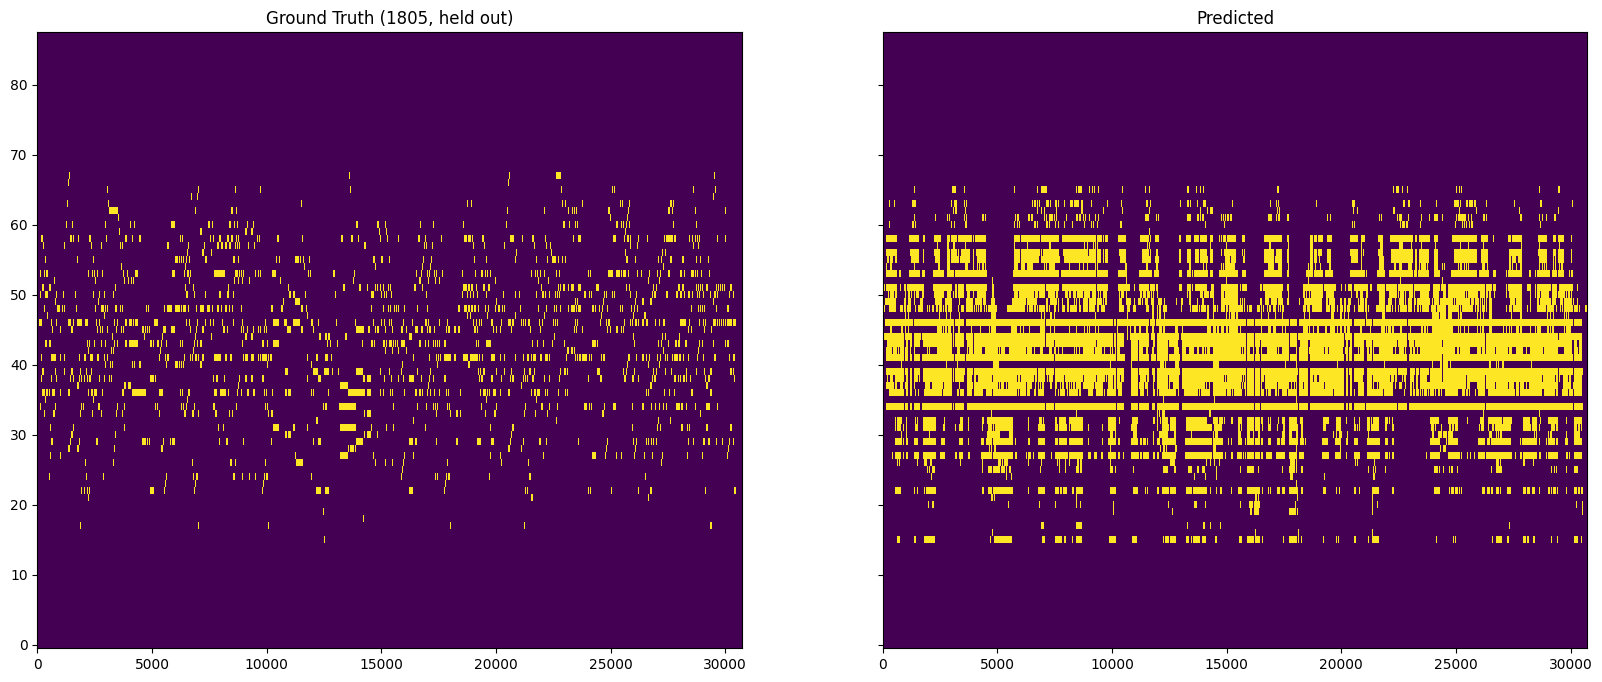

In [2]:
import torch
import librosa
import soundfile
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

print(torch.__version__)
print(torch.cuda.is_available())

data_dir = "/kaggle/input/datasets/shogohuangg/training-scaffold"

training_files = [1807, 2105, 2177, 2178, 2179, 2180, 2186, 2191, 2241, 2242, 2243, 2244, 2288, 2289, 2313, 2314, 2315, 2431, 2432, 2659]
test_files = [1805, 1788, 1789, 1790, 1793]

assert not set(training_files)& set(test_files), "overlap between train and test"
print(len(training_files), "training files, ", len(test_files), "testing files")

missing = []
for p in training_files + test_files:
    if not os.path.exists(f"{data_dir}/{p}.wav"): missing.append(f"{p}.wav")
    if not os.path.exists(f"{data_dir}/{p}.csv"): missing.append(f"{p}.csv")
assert not missing, f"missing: {missing}"
 
train_audio = [f"{data_dir}/{p}.wav" for p in training_files]
train_notes = [f"{data_dir}/{p}.csv" for p in training_files]
test_audio  = [f"{data_dir}/{p}.wav" for p in test_files]
test_notes  = [f"{data_dir}/{p}.csv" for p in test_files]


class MusicDataset(Dataset):
    def __init__(self, audio_files, label_files):
        self.audio_files = audio_files
        self.label_files = label_files

    def __len__(self):
        return len(self.audio_files)

    def __getitem__(self, index):
        audio_path = self.audio_files[index]
        label_path = self.label_files[index]
        y, sr = librosa.load(audio_path, sr=None)
        D = librosa.stft(y)
        S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
        S_db = (S_db - S_db.mean()) / (S_db.std() + 1e-6)
        spectrogram_tensor = torch.tensor(S_db, dtype=torch.float32)
        spectrogram_tensor = spectrogram_tensor.unsqueeze(0)

        labels_df = pd.read_csv(label_path)
        hop_length = 512
        n_frame = spectrogram_tensor.shape[-1]
        piano_roll = torch.zeros(n_frame, 88)

        for _, row in labels_df.iterrows():
            start_frame = int(row['start_time']) // hop_length
            end_frame = int(row['end_time']) // hop_length
            pitch_idx = int(row['note']) - 21
            if 0 <= pitch_idx < 88:
                piano_roll[start_frame:end_frame, pitch_idx] = 1

        return spectrogram_tensor, piano_roll


train_dataset = MusicDataset(train_audio, train_notes)
test_dataset = MusicDataset(test_audio, test_notes)
dataset = train_dataset
    
spectrogram, piano_roll = dataset[0]
print("Spectrogram shape:", spectrogram.shape)
print("Piano roll shape:", piano_roll.shape)

plt.figure(figsize=(15,10))
plt.imshow(piano_roll.T, aspect='auto', origin='lower')
plt.xlabel("Time frame")
plt.ylabel("Pitch")
plt.title("Piano Roll Sanity Check")
plt.show()


class CRNN(nn.Module):
    def __init__(self, num_freq_bins=1025, cnn_channels=16, hidden_size=128, num_classes=88):
        super(CRNN, self).__init__()
        self.conv1 = nn.Conv2d(1, cnn_channels, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d((2,1))   

        self.conv2 = nn.Conv2d(cnn_channels, cnn_channels*2, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d((4,1))  

        self.conv3 = nn.Conv2d(cnn_channels*2, cnn_channels*2, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d((4,1))

        lstm_input = cnn_channels*2*32  

        self.lstm = nn.LSTM(input_size=lstm_input, hidden_size=hidden_size, num_layers=2,
                             batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        batch_size, channels, freq, time = x.shape
        x = x.permute(0,3,1,2).reshape(batch_size, time, channels*freq)
        x, _ = self.lstm(x)
        x = self.fc(x)
        return x

CHUNK_LEN = 300

def chunkify(spec, roll=None, chunk_len=CHUNK_LEN):
    T = spec.shape[-1]
    pad = (-T) % chunk_len
    if pad:
        spec = torch.nn.functional.pad(spec, (0, pad))
        if roll is not None:
            roll = torch.nn.functional.pad(roll, (0, 0, 0, pad))
    n = spec.shape[-1] // chunk_len
    X = spec.reshape(1, spec.shape[1], n, chunk_len).permute(2, 0, 1, 3).contiguous()
    Y = roll.reshape(n, chunk_len, 88).contiguous() if roll is not None else None
    return X, Y, T

@torch.no_grad()
def predict_full(model, spec, batch=8):
    X, _, T = chunkify(spec)
    was_training = model.training
    model.eval()
    out = [torch.sigmoid(model(X[i:i+batch].cuda())).cpu() for i in range(0, len(X), batch)]
    if was_training:
        model.train()
    return torch.cat(out).reshape(-1, 88)[:T]
    
model = CRNN().cuda()
print(model)
output = model(spectrogram.unsqueeze(0)[:, :, :, :CHUNK_LEN].cuda())
print(output.shape)

def build_chunks(ds, name):
    Xs, Ys = [], []
    for i in range(len(ds)):
        spec, roll = ds[i]
        Xi, Yi, Ti, = chunkify(spec, roll)
        Xs.append(Xi)
        Ys.append(Yi)
        print(f"  {name} piece {i+1}/{len(ds)}: {Xi.shape[0]} chunks ({Ti} frames)")
    X=torch.cat(Xs)
    Y=torch.cat(Ys)
    print(f"{name}: {X.shape[0]} chunks total")
    return X, Y

print("Loading training")
X, Y = build_chunks(train_dataset, "train")
print("Loaidng testing")
Xt, Yt = build_chunks(test_dataset, "test")

n_chunks=X.shape[0]
n_test_chunks=Xt.shape[0]

epochs = 100
train_loss_history = []
test_loss_history = []


num_pos = Y.sum()
num_neg = Y.numel()-num_pos
pos_weight = (num_neg/num_pos).clone().detach().cuda()
pos_weight = torch.clamp(pos_weight, max=20.0)
print("pos_weight:", pos_weight.item())

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=8)

best_test_loss = float('inf')
best_train_at_best=None
best_epoch=-1
best_state=None
epochs_since_improve=0
patience=20

for epoch in range(epochs):
    model.train()
    perm = torch.randperm(n_chunks)
    running = 0.0
    for i in range(0, n_chunks, 8):
        idx = perm[i:i+8]
        xb, yb = X[idx].cuda(), Y[idx].cuda()
        optimizer.zero_grad()
        output = model(xb)
        loss = criterion(output, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running += loss.item() * xb.size(0)

    epoch_loss = running / n_chunks
    train_loss_history.append(epoch_loss)
    model.eval()
    test_running = 0.0
    with torch.no_grad():
        for i in range(0, n_test_chunks, 8):
            xb, yb = Xt[i:i+8].cuda(), Yt[i:i+8].cuda()
            test_running += criterion(model(xb), yb).item() * xb.size(0)

    epoch_test_loss=test_running/n_test_chunks
    test_loss_history.append(epoch_test_loss)
    scheduler.step(epoch_test_loss)

    if epoch_test_loss < best_test_loss:
        best_test_loss = epoch_test_loss
        best_train_at_best = epoch_loss
        best_epoch = epoch
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_since_improve = 0
    else:
        epochs_since_improve += 1

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {epoch_loss:.4f}, Test Loss: {test_loss_history[-1]:.4f}")
    if epochs_since_improve >= patience:
        print(f"Early stop at epoch {epoch+1}. Best epoch: {best_epoch+1}.")
        break
        
model.load_state_dict(best_state)
print(f" best epoch:       {best_epoch+1}")
print(f" test loss @ best: {best_test_loss:.4f}")
print(f" train @ best:     {best_train_at_best:.4f}  |  gap: {best_test_loss - best_train_at_best:+.4f}")


print("Per-piece held-out loss:")
for i in range(len(test_dataset)):
    spec_i, roll_i = test_dataset[i]
    Xi, Yi, _ = chunkify(spec_i, roll_i)
    with torch.no_grad():
        run = 0.0
        for j in range(0, Xi.shape[0], 8):
            xb, yb = Xi[j:j+8].cuda(), Yi[j:j+8].cuda()
            run += criterion(model(xb), yb).item() * xb.size(0)
    print(f"  {test_files[i]}: {run/Xi.shape[0]:.4f}")

plt.figure(figsize=(15,10))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss")
plt.plot(train_loss_history, label="Train Loss")
plt.plot(test_loss_history, label="Test Loss")
plt.axvline(best_epoch, ls="--", c="k", lw=1, label=f"best epoch {best_epoch+1}")
plt.legend()
plt.show()


test_spectrogram, test_piano_roll = test_dataset[0]
probs = predict_full(model, test_spectrogram)
preds = (probs > 0.5).float()

print("probs min/max/mean:", probs.min().item(), probs.max().item(), probs.mean().item())

fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
axes[0].imshow(test_piano_roll[:preds.shape[0]].T, aspect='auto', origin='lower', interpolation='nearest')
axes[0].set_title(f"Ground Truth ({test_files[0]}, held out)")
axes[1].imshow(preds.T, aspect='auto', origin='lower', interpolation='nearest')
axes[1].set_title("Predicted")
plt.show()
